# Assumption: the data from all the treated reservoirs is available up to the same date

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import numpy as np
from sklearn.metrics.pairwise import haversine_distances

# Setting up the path to include the parent directory
sys.path.append(str(Path.cwd().parent.parent))
from backend.config.settings import PATHS
from backend.modeling.sarima_model import SARIMAModel
from backend.modeling.prophet_model import ProphetModel
from backend.modeling.xgboost_model import XGBoostModel
from backend.transferring.predicting import predict_one_year
from sklearn.linear_model import LinearRegression

In [4]:
water_path = PATHS['definitive'] / 'water_definitive.csv'
water_pd = pd.read_parquet(water_path)
water_pd.head()

,date,storage,id
0,2012-09-04,56,18
1,2012-10-23,50,18
2,2012-11-27,55,18
3,1991-01-22,53,18
4,1991-05-21,52,18


In [7]:
reservoirs_path = PATHS['definitive'] / 'reservoirs_definitive.csv'
reservoirs_pd = pd.read_parquet(reservoirs_path)
reservoirs_pd.head()

,id,scope,name,capacity,electric_flag,latitude,longitude,basin,riverbed,google,openstreetmap,wikidata,province,autonomous_community,type,crest_elevation,dam_height,report
0,3,guadalquivir,fernandina,247,0,38.179646,-3.570224,guadalquivir,rio guarrizas,None,None,None,jaen,andalucia,presa fabrica gravedad (hormigon vibrado),719.55,NaN,https://sig.mapama.gob.es/WebServices/clientew...
1,5,guadalquivir,puebla cazalla,87,0,37.129772,-5.243309,guadalquivir,rio corbones,None,None,None,sevilla,andalucia,presa fabrica gravedad (hormigon compactado),218.25,NaN,https://sig.mapama.gob.es/WebServices/clientew...
2,9,cuenca mediterranea andaluza,vinuela,170,0,36.860400,-4.164435,cuencas mediterraneas andaluzas,rio guaro,https://www.google.com/search?kgmid=/g/120jr2sh,None,https://www.wikidata.org/wiki/Q5830515,malaga,andalucia,presa materiales sueltos pantalla hormigon,426.00,NaN,https://sig.mapama.gob.es/WebServices/clientew...
3,11,cuenca mediterranea andaluza,rules,111,0,36.860510,-3.495430,cuencas mediterraneas andaluzas,rio guadalfeo o rio cadiar,https://www.google.com/search?kgmid=/g/121vx8sj,None,https://www.wikidata.org/wiki/Q5369455,granada,andalucia,presa fabrica arco gravedad,426.00,NaN,https://sig.mapama.gob.es/WebServices/clientew...
4,12,guadiana,burdalo,79,0,NaN,NaN,None,None,None,None,None,caceres,extremadura,None,NaN,NaN,None


In [ ]:
from backend.transferring.predicting import predict_one_year
critical_threshold = 0.075
worrying_threshold = 0.15
could_give_if_critical = 0.25
could_give_if_worrying = 0.35
able_to_donate = 0.6
cost_threshold = 6


def initial_state(reservoirs, critical_threshold=critical_threshold, worrying_threshold=worrying_threshold, could_give_if_critical=could_give_if_critical, could_give_if_worrying=could_give_if_worrying, able_to_donate=able_to_donate):
    water_restricted = water_pd[water_pd['id'].isin(reservoirs)]
    reservoirs_restricted = reservoirs_pd[reservoirs_pd['id'].isin(reservoirs)]

    reservoirs = sorted(reservoirs_restricted['id'].unique())
    first_reservoir_data = water_restricted[water_restricted['id']==reservoirs[0]].sort_values(by='date')
    first_week_considered = first_reservoir_data.iloc[-52]['date']
    series_index = pd.date_range(start=first_week_considered, periods=52*2, freq='7D')

    water_definitive = pd.DataFrame()
    for reservoir in reservoirs_restricted['id']:
        water_one_reservoir = pd.DataFrame()
        water_one_reservoir.loc[:, 'date'] = series_index
        water_one_reservoir.loc[water_one_reservoir['date'] < water_one_reservoir['date'][52], 'storage'] = water_restricted[water_restricted['id'] == reservoir].sort_values(by='date')['storage'][-52:].values
        water_one_reservoir.loc[water_one_reservoir['date'] >= water_one_reservoir['date'][52], 'storage'] = predict_one_year(reservoir, 4, plotting=False).values
        water_one_reservoir.loc[:, 'id'] = reservoir
        water_definitive = pd.concat([water_definitive, water_one_reservoir], axis=0, ignore_index=True)

    water_definitive.sort_values(by=['id', 'date'], inplace=True)

    reservoirs_definitive = reservoirs_restricted[['id', 'name', 'capacity', 'latitude', 'longitude', 'crest_elevation']]
    reservoirs_definitive.set_index('id', inplace=True)
    for reservoir in reservoirs:
        reservoirs_definitive.loc[reservoir, 'last_known_value'] = water_definitive[water_definitive['id'] == reservoir].sort_values(by='date')['storage'].values[-53]
        reservoirs_definitive.loc[reservoir, 'low_forecasted_value'] = water_definitive[water_definitive['id'] == reservoir][-52:].sort_values(by='storage')['storage'].values[5]
        reservoirs_definitive.loc[reservoir, 'high_forecasted_value'] = water_definitive[water_definitive['id'] == reservoir][-52:].sort_values(by='storage')['storage'].values[-5]
        reservoirs_definitive.loc[reservoir, 'median_forecasted_value'] = water_definitive[water_definitive['id'] == reservoir][-52:].sort_values(by='storage')['storage'].values[26]

    reservoirs_definitive['urgent_need_to_receive_rate'] = reservoirs_definitive['low_forecasted_value'] / reservoirs_definitive['capacity']
    reservoirs_definitive['ability_to_transfer_rate'] = reservoirs_definitive['median_forecasted_value']  / reservoirs_definitive['capacity']
    reservoirs_definitive['critical'] = (reservoirs_definitive['urgent_need_to_receive_rate'] < critical_threshold).astype(int)
    reservoirs_definitive['worrying'] = (reservoirs_definitive['urgent_need_to_receive_rate'] < worrying_threshold).astype(int)
    reservoirs_definitive['could_give_if_critical'] = (reservoirs_definitive['ability_to_transfer_rate'] > could_give_if_critical).astype(int)
    reservoirs_definitive['could_give_if_worrying'] = (reservoirs_definitive['ability_to_transfer_rate'] > could_give_if_worrying).astype(int)
    reservoirs_definitive['able_to_donate'] = (reservoirs_definitive['ability_to_transfer_rate'] > able_to_donate).astype(int)

    coords_rad = np.radians(reservoirs_definitive[['latitude','longitude']].to_numpy())
    distance_matrix = haversine_distances(coords_rad, coords_rad) * 6371.0  # shape (N,N) in km
    # cost_matrix[i,j] means the cost of reservoir i to transfer water to reservoir j
    value_matrix = distance_matrix.copy()
    value_matrix = value_matrix / value_matrix.max()  # Normalize distances by the maximum distance in each row
    value_matrix = 4*value_matrix
    value_matrix = 1 / value_matrix

    median_capacity = reservoirs_definitive['capacity'].values[len(reservoirs) // 2]

    for i in range(len(reservoirs)):
        # The next operation only depends on the donor reservoir's characteristics, not the receiver
        value_matrix[i, :] = value_matrix[i, :] * (reservoirs_definitive.loc[reservoirs[i], 'capacity'] / median_capacity) * reservoirs_definitive.loc[reservoirs[i], 'ability_to_transfer_rate']
        # The next operation only depends on the receiver reservoir's characteristics, not the donor
        value_matrix[:, i] = value_matrix[:, i] / reservoirs_definitive.loc[reservoirs[i], 'urgent_need_to_receive_rate']

    cost_matrix = 1 / value_matrix


    for i  in range(len(reservoirs)):
        cost_matrix[i,i] = np.inf
        if not (reservoirs_definitive.loc[reservoirs[i], 'could_give_if_critical']):
            cost_matrix[i,:] = np.full(len(reservoirs), np.inf)

    return reservoirs_definitive, cost_matrix

In [242]:
def update_cost_matrix(donor, receiver, cost_matrix, distance_matrix, reservoirs_definitive):
    id_to_index = {id: i for i, id in enumerate(reservoirs_definitive.index)}
    def update_cost_matrix_one_reservoir(reservoir, id_reservoir):
        cost_matrix[reservoir,:] = 1 / (4 * distance_matrix[reservoir, :] / distance_matrix.max())
        cost_matrix[:, reservoir] = 1 / (4 * distance_matrix[:, reservoir] / distance_matrix.max())
        median_capacity = reservoirs_definitive['capacity'].values[len(reservoirs_definitive.index) // 2]
        cost_matrix[reservoir, :] = cost_matrix[reservoir, :] * (reservoirs_definitive.loc[id_reservoir, 'capacity'] / median_capacity) * reservoirs_definitive.loc[id_reservoir, 'ability_to_transfer_rate']
        cost_matrix[:, reservoir] = cost_matrix[:, reservoir] / reservoirs_definitive.loc[id_reservoir, 'urgent_need_to_receive_rate']
        cost_matrix[reservoir, :] = 1 / cost_matrix[reservoir, :]
        cost_matrix[:, reservoir] = 1 / cost_matrix[:, reservoir]
        cost_matrix[reservoir, reservoir] = np.inf
        if not reservoirs_definitive.loc[id_reservoir, 'could_give_if_critical']:
            cost_matrix[reservoir, :] = np.full(len(reservoirs_definitive.index), np.inf)

    update_cost_matrix_one_reservoir(id_to_index[donor], donor)
    update_cost_matrix_one_reservoir(id_to_index[receiver], receiver)


#### To stop the search for transfers: suppose a distance of 3 (=0.75*max_distance_between_reservoirs).
#### It's value is 0.33. Then, suppose the reservoir that is offering water has half
#### of the median capacity. In this case, the effective value
#### of the transfer would be 0.33 * 0.5 = 0.165, and that the ability
#### to transfer is 0.4. Then, the result would be 0.165 * 0.4 = 0.066.
#### Suppose now that the reservoir that is receiving water has 0.4 of urgency to receive. 0.066 * 2.5 = 0.165
#### Inverting, looking, for costs, we would have:
#### cost = 1 / (0.165) = 6.061.

In [238]:
critical_threshold = 0.075
worrying_threshold = 0.15
could_give_if_critical = 0.25
could_give_if_worrying = 0.35
able_to_donate = 0.6
cost_threshold = 6


def perform_best_transfer(reservoirs_definitive, cost_matrix, cost_threshold, accept_worrying=False):
    def perform_best_transfer_for_given_columns(columns, state_receiver):
        i = 0
        index_to_id = {i: id for i, id in enumerate(reservoirs_definitive.index)}
        sorted_costs = np.sort(cost_matrix[:, columns], axis=None)
        while i < len(sorted_costs) and sorted_costs[i] < cost_threshold:
            # Get the indices of the reservoirs involved in this transfer
            reservoir_pair = np.unravel_index(np.where(cost_matrix == sorted_costs[i]), cost_matrix.shape)
            donor = reservoir_pair[0]
            donor = index_to_id[donor]
            receiver = reservoir_pair[1]
            receiver = index_to_id[receiver]

            if reservoirs_definitive.loc[donor, f'could_give_if_{state_receiver}']:

                temptative_reservoirs_definitive = update_reservoirs_equal_percentage(reservoirs_definitive, donor, receiver, state_receiver)

                if state_receiver == 'critical':
                    if (not temptative_reservoirs_definitive.loc[receiver, 'worrying']) and (not temptative_reservoirs_definitive.loc[donor, 'worrying']):
                        return temptative_reservoirs_definitive, True
                    elif accept_worrying and (not temptative_reservoirs_definitive.loc[receiver, 'critical']):
                        break
                    else:
                        i += 1
                        continue
                
                if state_receiver == 'worrying':
                    if ( not temptative_reservoirs_definitive.loc[receiver, 'worrying']) and (not temptative_reservoirs_definitive.loc[donor, 'worrying']):
                        return temptative_reservoirs_definitive, True
                    else:
                        i += 1
        False  

    id_to_index = {id: i for i, id in enumerate(reservoirs_definitive.index)}
    critical_indices = reservoirs_definitive[reservoirs_definitive['critical']==1].index.map(id_to_index).values
    reservoirs_definitive, bool = perform_best_transfer_for_given_columns(critical_indices, 'critical')
    if not bool:
        worrying_indices = reservoirs_definitive[reservoirs_definitive['worrying']==1].index.map(id_to_index).values
        reservoirs_definitive, bool = perform_best_transfer_for_given_columns(worrying_indices, 'worrying')
        if not bool:
            return reservoirs_definitive, False
        return reservoirs_definitive, True

In [ ]:
def update_reservoirs_equal_percentage(reservoirs_definitive, donor, receiver):
    capacity_donor = reservoirs_definitive.loc[donor, 'capacity']
    capacity_receiver = reservoirs_definitive.loc[receiver, 'capacity']
    current_storage_donor = reservoirs_definitive.loc[donor, 'last_known_value']
    current_storage_receiver = reservoirs_definitive.loc[receiver, 'last_known_value']
    ponderation_donor = capacity_donor / (capacity_donor + capacity_receiver)
    difference = current_storage_donor - ponderation_donor * (current_storage_donor + current_storage_receiver)

    def update_one_reservoir(reservoir, difference):
        reservoirs_definitive.loc[reservoir, ['last_known_value', 'low_forecasted_value', 'high_forecasted_value', 'median_forecasted_value']] += difference
        reservoirs_definitive.loc[reservoir, 'urgent_need_to_receive_rate'] = reservoirs_definitive.loc[reservoir, 'low_forecasted_value'] / reservoirs_definitive.loc[reservoir, 'capacity']
        reservoirs_definitive.loc[reservoir, 'ability_to_transfer_rate'] = reservoirs_definitive.loc[reservoir, 'median_forecasted_value'] / reservoirs_definitive.loc[reservoir, 'capacity']
        reservoirs_definitive.loc[reservoir, 'critical'] = (reservoirs_definitive.loc[reservoir, 'urgent_need_to_receive_rate'] < critical_threshold).astype(int)
        reservoirs_definitive.loc[reservoir, 'worrying'] = (reservoirs_definitive.loc[reservoir, 'urgent_need_to_receive_rate'] < worrying_threshold).astype(int)
        reservoirs_definitive.loc[reservoir, 'could_give_if_critical'] = (reservoirs_definitive.loc[reservoir, 'ability_to_transfer_rate'] > could_give_if_critical).astype(int)
        reservoirs_definitive.loc[reservoir, 'could_give_if_worrying'] = (reservoirs_definitive.loc[reservoir, 'ability_to_transfer_rate'] > could_give_if_worrying).astype(int)
        reservoirs_definitive.loc[reservoir, 'able_to_donate'] = (reservoirs_definitive.loc[reservoir, 'ability_to_transfer_rate'] > able_to_donate).astype(int)

    update_one_reservoir(donor, -difference)
    update_one_reservoir(receiver, difference)

    return reservoirs_definitive


In [241]:
def show_best_transfers(reservoirs_definitive, cost_matrix):
    def show_best_transfers_for_given_columns(columns):
        i = 0
        index_to_id = {i: id for i, id in enumerate(reservoirs_definitive.index)}
        sorted_costs = np.sort(cost_matrix[:, columns], axis=None)
        while i < len(sorted_costs) and sorted_costs[i] < cost_threshold:
            # Get the indices of the reservoirs involved in this transfer
            reservoir_pair = np.unravel_index(np.where(cost_matrix == sorted_costs[i]), cost_matrix.shape)
            donor = reservoir_pair[0]
            donor = index_to_id[donor]
            receiver = reservoir_pair[1]
            receiver = index_to_id[receiver]

            transfers = pd.DataFrame(columns=['donor', 'receiver', 'cost', 'critical', 'worrying', 'could_give_if_critical', 'could_give_if_worrying', 'able_to_donate'])
            transfers = transfers.append({'donor': donor, 'receiver': receiver, 'cost': sorted_costs[i],
                                           'critical': reservoirs_definitive.loc[receiver, 'critical'],
                                           'worrying': reservoirs_definitive.loc[receiver, 'worrying'],
                                           'could_give_if_critical': reservoirs_definitive.loc[donor, 'could_give_if_critical'],
                                           'could_give_if_worrying': reservoirs_definitive.loc[donor, 'could_give_if_worrying'],
                                           'able_to_donate': reservoirs_definitive.loc[donor, 'able_to_donate']}, ignore_index=True)

        return transfers
    

    id_to_index = {id: i for i, id in enumerate(reservoirs_definitive.index)}
    critical_indices = reservoirs_definitive[reservoirs_definitive['critical']==1].index.map(id_to_index).values
    critical_transfers = show_best_transfers_for_given_columns(critical_indices)
    worrying_indices = reservoirs_definitive[reservoirs_definitive['worrying']==1].index.map(id_to_index).values
    worrying_indices = [i for i in worrying_indices if i not in critical_indices]
    worrying_transfers = show_best_transfers_for_given_columns(worrying_indices)
    rest_of_indices = [i for i in id_to_index.values() if i not in critical_indices and i not in worrying_indices]
    rest_of_transfers = show_best_transfers_for_given_columns(rest_of_indices)
    return pd.concat([critical_transfers, worrying_transfers, rest_of_transfers], axis=0, ignore_index=True)

In [236]:
update_reservoirs_equal_percentage(reservoirs_definitive, 288, 241)

,name,capacity,latitude,longitude,crest_elevation,last_known_value,low_forecasted_value,high_forecasted_value,median_forecasted_value,urgent_need_to_receive_rate,ability_to_transfer_rate,critical,worrying,could_give_if_critical,could_give_if_worrying,able_to_donate
id,,,,,,,,,,,,,,,,
9,vinuela,170,36.860400,-4.164435,426.0,24.000000,22.366365,29.569392,24.041903,0.131567,0.141423,0,1,0,0,0
241,limonero,25,36.758417,-4.432465,426.0,8.333333,6.030709,7.635362,7.328926,0.241228,0.293157,0,0,1,0,0
288,concepcion,62,36.535398,-4.960755,107.2,20.666667,15.246985,28.100765,20.144360,0.245919,0.324909,0,0,1,0,0
478,conde guadalhorce,83,36.933302,-4.803749,250.0,12.000000,9.653620,22.446314,12.332750,0.116309,0.148587,0,1,0,0,0
569,guadalteba,312,36.940192,-4.800475,250.0,32.000000,12.434000,27.911442,23.803332,0.039853,0.076293,1,1,0,0,0
704,casasola,23,36.804412,-4.495712,426.0,5.000000,3.768188,4.997428,4.359062,0.163834,0.189524,0,0,0,0,0


In [223]:
reservoirs_definitive

,name,capacity,latitude,longitude,crest_elevation,last_known_value,low_forecasted_value,high_forecasted_value,median_forecasted_value,urgent_need_to_receive_rate,ability_to_transfer_rate,critical,worrying,could_give_if_critical,could_give_if_worrying,able_to_donate
id,,,,,,,,,,,,,,,,
9,vinuela,170,36.860400,-4.164435,426.0,24.0,22.366365,29.569392,24.041903,0.131567,0.141423,0,1,0,0,0
241,limonero,25,36.758417,-4.432465,426.0,4.0,1.697376,3.302028,2.995592,0.067895,0.119824,1,1,0,0,0
288,concepcion,62,36.535398,-4.960755,107.2,25.0,19.580318,32.434098,24.477693,0.315812,0.394802,0,0,1,1,0
478,conde guadalhorce,83,36.933302,-4.803749,250.0,12.0,9.653620,22.446314,12.332750,0.116309,0.148587,0,1,0,0,0
569,guadalteba,312,36.940192,-4.800475,250.0,32.0,12.434000,27.911442,23.803332,0.039853,0.076293,1,1,0,0,0
704,casasola,23,36.804412,-4.495712,426.0,5.0,3.768188,4.997428,4.359062,0.163834,0.189524,0,0,0,0,0


In [231]:
cost_matrix[:, reservoirs_definitive[reservoirs_definitive['critical']==1].index.map(id_to_index).values]

array([[       inf,        inf],
       [       inf,        inf],
       [0.61562803, 0.32041254],
       [       inf,        inf],
       [       inf,        inf],
       [       inf,        inf]])

In [ ]:
np.sort(cost_matrix, axis=None)

C:\Users\usuario\AppData\Local\Temp\ipykernel_3248\4239449150.py:5: RuntimeWarning: divide by zero encountered in divide
  value_matrix = 1 / value_matrix


array([0.32041254, 0.61562803, 0.91891063, 1.42642291, 1.78448984,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf])

In [215]:
reservoirs_malaga, cost_matrix_malaga = initial_state(reservoirs_pd[reservoirs_pd['province'] == 'malaga']['id'].values)
cost_matrix_malaga

C:\Users\usuario\AppData\Local\Temp\ipykernel_3248\2790711591.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reservoirs_definitive.loc[reservoir, 'last_known_value'] = water_definitive[water_definitive['id'] == reservoir].sort_values(by='date')['storage'].values[-53]
C:\Users\usuario\AppData\Local\Temp\ipykernel_3248\2790711591.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reservoirs_definitive.loc[reservoir, 'low_forecasted_value'] = water_definitive[water_definitive['id'] == reservoir][-52:].

array([[       inf,        inf,        inf,        inf,        inf,
               inf],
       [       inf,        inf,        inf,        inf,        inf,
               inf],
       [1.78448984, 0.61562803,        inf, 0.91891063, 0.32041254,
        1.42642291],
       [       inf,        inf,        inf,        inf,        inf,
               inf],
       [       inf,        inf,        inf,        inf,        inf,
               inf],
       [       inf,        inf,        inf,        inf,        inf,
               inf]])

In [237]:
reservoirs = list(reservoirs_pd[reservoirs_pd['province'] == 'malaga']['id'])
sorted(reservoirs)

[9, 241, 288, 478, 569, 704]

In [45]:
next_year_path = PATHS['processed_data'] / 'next_year_predictions.parquet'
next_year_pd = pd.read_parquet(next_year_path)
next_year_pd.head()

,9,241,288,478,569,704,113,212,240,242,326,328,375,571,623,624,324,570
2024-10-01,24.000000,4.000000,25.000000,12.000000,32.000000,5.000000,27.000000,25.000000,3.000000,30.000000,18.000000,139.000000,90.000000,6.000000,13.000000,46.000000,5.000000,13.000000
2024-10-08,23.367174,3.739510,23.247850,11.241825,31.114505,5.035830,26.009747,23.147980,2.864101,29.332606,17.705750,133.954399,87.752136,5.860489,12.757902,45.073878,4.963770,13.016359
2024-10-15,23.008188,3.730655,21.299127,10.538347,29.730690,5.044032,25.331013,22.755719,2.765643,28.575131,16.877223,130.546135,85.863477,5.491457,12.847115,44.407259,4.902604,12.950152
2024-10-22,22.986373,3.707034,20.324210,10.091056,28.703733,5.040350,25.058914,22.531331,2.699903,27.925427,16.457903,129.382539,84.769342,5.404766,12.846680,44.297686,4.844504,12.729628
2024-10-29,22.909292,3.302028,19.884642,9.859344,27.911442,4.997428,24.896860,22.483103,2.664024,27.676867,16.033248,129.020704,83.933202,5.401935,12.823727,44.396300,4.697395,12.544252


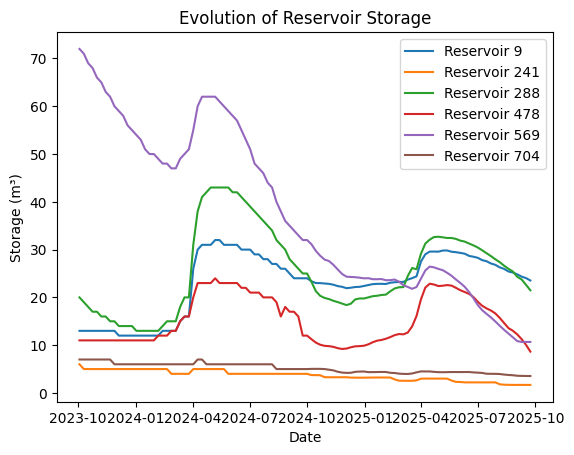

In [150]:
# Plot the evolution of storage or every reservoir at water_definitive

for reservoir in water_definitive['id'].unique():
    plt.plot(water_definitive[water_definitive['id'] == reservoir]['date'],
             water_definitive[water_definitive['id'] == reservoir]['storage'],
             label=f'Reservoir {reservoir}')

plt.xlabel('Date')
plt.ylabel('Storage (m³)')
plt.title('Evolution of Reservoir Storage')
plt.legend()
plt.show()